In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка данных
data = pd.read_csv('/content/dataset_for_SI.csv')

# Разделение на признаки и целевую переменную
X = data.drop('SI', axis=1)
y = data['SI']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Будем пробовать обучать модели Random Forest, Gradient Boosting, XGBoost, SVR с перебором гиперпараметров. У части моделей сначала проведем отбор признаков

In [3]:
#Данные будем хравить в словаре
results = {}

In [4]:
# Random Forest
model_rf = RandomForestRegressor(n_estimators=50, random_state=42)

# Создаем пайплайн
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', model_rf)
])

params_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [20, 30, 50],
}

grid_rf = GridSearchCV(pipe_rf, params_rf, cv=10, scoring='r2')

grid_rf.fit(X_train, y_train)
y_pred_rf = grid_rf.best_estimator_.predict(X_test)
results['Random Forest'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf)
}

In [6]:
# Gradient Boosting
model_gb = GradientBoostingRegressor(random_state=42)

# Создаем пайплайн
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', model_gb)
])
params_gb = {
    'gb__n_estimators': [250, 300, 350],
    'gb__learning_rate': [0.05, 0.1, 0.2]
}
grid_gb = GridSearchCV(pipe_gb, params_gb, cv=10, scoring='r2')
grid_gb.fit(X_train, y_train)
y_pred_gb = grid_gb.best_estimator_.predict(X_test)
results['Gradient Boosting'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb),
    'MSE': mean_squared_error(y_test, y_pred_gb)
}

In [7]:
# XGBoost
model_xgb = XGBRegressor(random_state=42, eval_metric='logloss')
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', model_xgb)
])

params_xgb = {
    'xgb__n_estimators': [150, 200, 250],
    'xgb__learning_rate': [0.05, 0.1, 0.2]
}

grid_xgb = GridSearchCV(pipe_xgb, params_xgb, cv=10, scoring='r2')

grid_xgb.fit(X_train, y_train)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)
results['XGBoost'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_xgb),
    'R2': r2_score(y_test, y_pred_xgb),
    'MSE': mean_squared_error(y_test, y_pred_xgb)
}

In [8]:
#SVR
pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR()),
])

params_svr = {
    'svr__C': [40, 50, 100],
    'svr__epsilon': [0.005, 0.01, 0.05],
}
grid_svr = GridSearchCV(pipe_svr, params_svr, cv=10, scoring='r2')

grid_svr.fit(X_train, y_train)
y_pred_svr = grid_svr.best_estimator_.predict(X_test)
results['SVR'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_svr),
    'R2': r2_score(y_test, y_pred_svr),
    'MSE': mean_squared_error(y_test, y_pred_svr)
}

In [9]:
#Результаты
print(f"{'Model':<20} | {'MAPE':<8} | {'R2':<6} | {'MSE':<8}")
for model, metrics in results.items():
    print(f"{model:<20} | {metrics['MAPE']:.4f} | {metrics['R2']:.4f} | {metrics['MSE']:.4f}")


Model                | MAPE     | R2     | MSE     
Random Forest        | 3.7035 | 0.0487 | 68.8955
Gradient Boosting    | 3.4010 | 0.1032 | 64.9482
XGBoost              | 3.5468 | -0.0109 | 73.2086
SVR                  | 2.2558 | -0.0088 | 73.0541


# Обучение на прологарифмированных данных

Так как при подготовке EDA мы предположили, что распределение исходных данных по таргетному признаку СC50 является лог-нормальным и обучение на обработанных "исходных" данных дает неудовлетворительные результаты, проверим распределение на прологарифмированных данных по таргетному признаку.

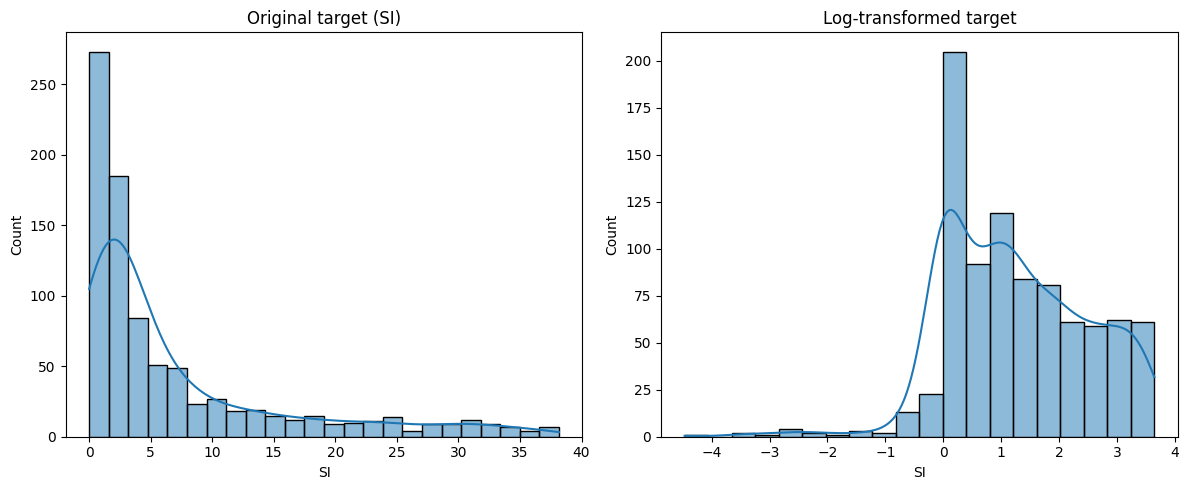

In [10]:
y_log = np.log(y + 1e-10)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True)
plt.title('Original target (SI)')

plt.subplot(1, 2, 2)
sns.histplot(y_log, kde=True)
plt.title('Log-transformed target')

plt.tight_layout()
plt.show()

Так как логарифм-таргет выглядит лучше, попробуем провести обучение на нем. Оценки метрик будем проводить в исходном масштабе данных.

In [11]:
#Поделим выборку с учетом лог-целевой переменной на обучающую и тестовую выборки
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [12]:
# Вычисляем коэффициент детерминации R² после обратного преобразования логарифма
def custom_r2_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return r2_score(true_values, predicted_values)


# Вычисляем среднюю абсолютную процентную ошибку (MAPE) после обратного преобразования логарифма
def custom_mape_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return mean_absolute_percentage_error(true_values, predicted_values)


# Вычисляем среднеквадратичную ошибку (MSE) после обратного преобразования логарифма
def custom_mse_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return mean_squared_error(true_values, predicted_values)

In [ ]:
# Random Forest
grid_rf = GridSearchCV(pipe_rf, params_rf, cv=10, scoring=custom_r2_scorer)

grid_rf.fit(X_train, y_train_log)

# Gradient Boosting
grid_gb = GridSearchCV(pipe_gb, params_gb, cv=10, scoring=custom_r2_scorer)

grid_gb.fit(X_train, y_train_log)

# XGBoost
grid_xgb = GridSearchCV(pipe_xgb, params_xgb, cv=10, scoring=custom_r2_scorer)

grid_xgb.fit(X_train, y_train_log)

# Support Vector Regressor
grid_svr = GridSearchCV(pipe_svr, params_svr, cv=10, scoring=custom_r2_scorer)

grid_svr.fit(X_train, y_train_log)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             param_grid={'svr__C': [40, 50, 100],
                         'svr__epsilon': [0.005, 0.01, 0.05]},
             scoring=<function r2_exp_scorer at 0x00000228F588FBA0>)

In [13]:
results['Random Forest log-transformed'] = {
    'MAPE':custom_mape_scorer(grid_rf.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_rf.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_rf.best_estimator_, X_test, y_test_log),
}

results['Gradient Boosting log-transformed'] = {
    'MAPE': custom_mape_scorer(grid_gb.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_gb.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_gb.best_estimator_, X_test, y_test_log),
}

results['XGBoost log-transformed'] = {
    'MAPE':custom_mape_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
    'MSE':custom_mse_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
}

results['SVR log-transformed'] = {
    'MAPE': custom_mape_scorer(grid_svr.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_svr.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_svr.best_estimator_, X_test, y_test_log),
}

In [14]:
print(f"{'Model':<40} | {'MAPE':<8} | {'R2':<6} | {'MSE':<8}")
for model, metrics in results.items():
    print(f"{model:<40} | {metrics['MAPE']:.4f} | {metrics['R2']:.4f} | {metrics['MSE']:.4f}")

Model                                    | MAPE     | R2     | MSE     
Random Forest                            | 3.7035 | 0.0487 | 68.8955
Gradient Boosting                        | 3.4010 | 0.1032 | 64.9482
XGBoost                                  | 3.5468 | -0.0109 | 73.2086
SVR                                      | 2.2558 | -0.0088 | 73.0541
Random Forest log-transformed            | 1414287975.0711 | -674464505394333351936.0000 | 48844246485463686184960.0000
Gradient Boosting log-transformed        | 179796060.1817 | -5475825086129518592.0000 | 396555412596279803904.0000
XGBoost log-transformed                  | 34509433527.5096 | -182969242631049362538496.0000 | 13250504236845599450726400.0000
SVR log-transformed                      | 244409431.2503 | -17272135082743603200.0000 | 1250835909917167321088.0000


# Сравнение результатов нелог и лог данных

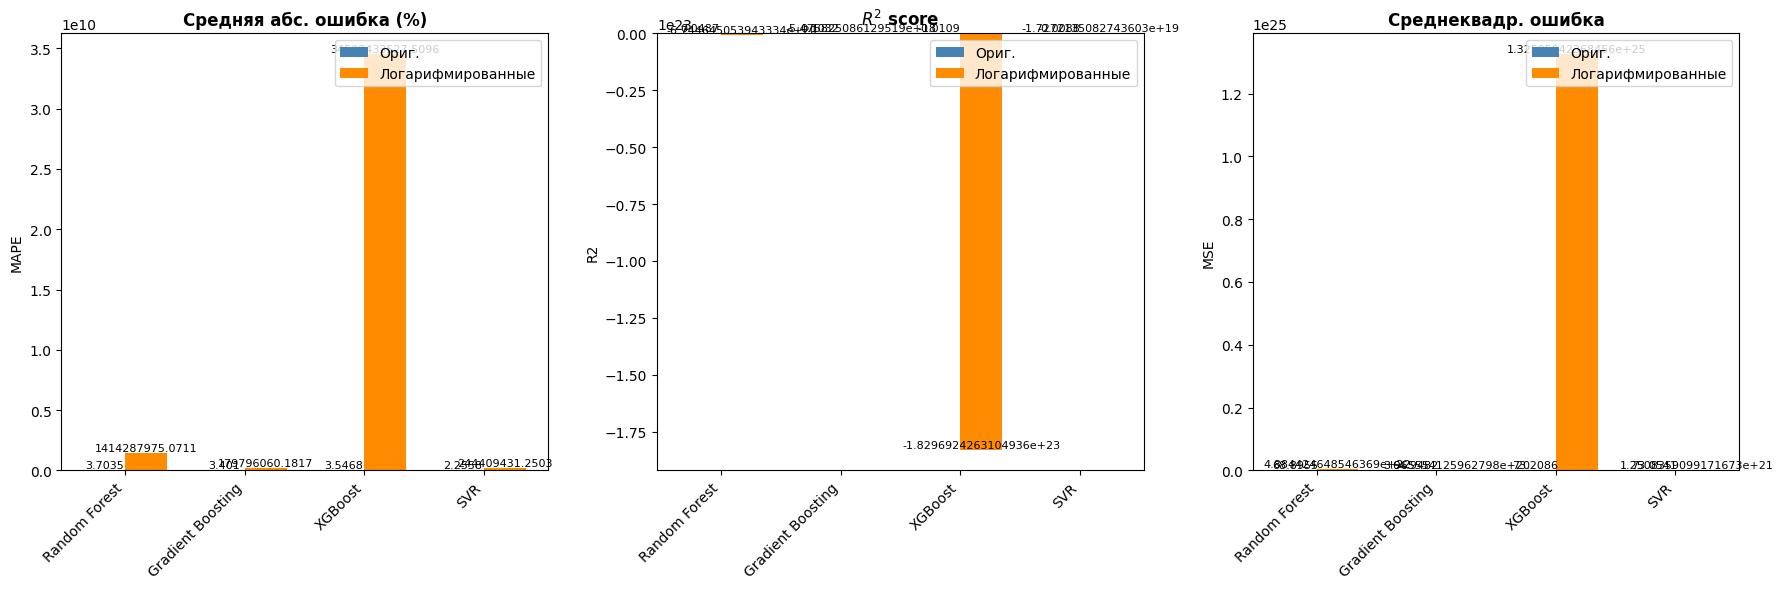

In [15]:
# Фильтруем модели с лог-преобразованиями и без
models_log = {name: data for name, data in results.items() if 'log' in name.lower()}
models_raw = {name: data for name, data in results.items() if 'log' not in name.lower()}

metrics = ['MAPE', 'R2', 'MSE']
titles = ['Средняя абс. ошибка (%)', '$R^2$ score', 'Среднеквадр. ошибка']

labels = list(models_raw.keys())
positions = np.arange(len(labels))
bar_width = 0.35  # Ширина одного столбика
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Собираем значения метрики для обеих групп моделей
    raw_values = [models_raw[name][metric] for name in labels]
    log_values = [models_log.get(name + ' log-transformed', {}).get(metric, 0) for name in labels]

    bars_original = ax.bar(positions - bar_width/2, raw_values, bar_width, label='Ориг.', color='steelblue')
    bars_transformed = ax.bar(positions + bar_width/2, log_values, bar_width, label='Логарифмированные', color='darkorange')



    ax.set_ylabel(metric)
    ax.set_title(titles[idx], fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.legend(loc='upper right', frameon=True)

    def add_labels(bars):
        for bar in bars:
            value = round(bar.get_height(), 4)
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   str(value), ha='center', va='bottom', fontsize=8)

    add_labels(bars_original)
    add_labels(bars_transformed)

plt.tight_layout()
plt.show()

Логарифмирование сильно ухудшило метрику R2, немного ухудшило MSE и вдвое понизило MAPE.
По совокупности показателей далее попробуем улучшить Gradient Boosting на нелогарифмированных данных.

Попробуем Обучить модель с подбором гиперпараметров из более широкого диапазона на нелогарифмированных данных.

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
y_pred = grid_search.predict(X_test)

results['Gradient Boosting tuned'] = {
    'MAPE': custom_mape_scorer(y_test, y_pred),
    'R2': custom_r2_scorer(y_test, y_pred),
    'MSE': custom_mse_scorer(y_test, y_pred),
}

In [ ]:
# Имена моделей и метрик
model_names = ['Gradient Boosting', 'Gradient Boosting log-transformed', 'Gradient Boosting filtered', 'Gradient Boosting tuned']
metrics = ['MAPE', 'R2', 'MSE']
titles = ['MAPE (%)', 'R² Score', 'MSE']

bar_width = 0.35
index = np.arange(len(model_names))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
    values = [results[name][metric] * 100 if metric == 'MAPE' else results[name][metric] for name in model_names]

    bars = ax.bar(index, values, bar_width, color=['skyblue', 'salmon', 'lightgreen'][i % 3])

    ax.set_xlabel('Модель')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.set_xticks(index)
    ax.set_xticklabels(model_names, rotation=45, ha='right')

    # Добавляем подписи к столбцам
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # смещение по вертикали
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
grid_search.best_params_

In [ ]:
grid_gb.best_params_